# Lab 04 — Fuzzy Logic and ANFIS with Air-Quality Data

**Worked Python solution.** This lab combines an interpretable Mamdani-style controller with a compact first-order Sugeno ANFIS regression model. No MATLAB code or toolbox is required.

The ANFIS implementation below uses Gaussian premise functions and a hybrid procedure: consequent coefficients are solved by ridge least squares while premise parameters are optimized on the training set. Model size is selected on validation data only.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=FutureWarning)

def find_project_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "all_datasets").exists():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the course project.")
ROOT=find_project_root()
print("Project root:",ROOT)

from itertools import product
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

RESULTS=ROOT/"results"/"lab04"; RESULTS.mkdir(parents=True,exist_ok=True)
DATA=ROOT/"all_datasets"/"lab04-AirQuality.csv"
df=pd.read_csv(DATA,sep=";",decimal=",")
df=df.drop(columns=[c for c in df.columns if str(c).startswith("Unnamed")]).dropna(how="all")
df=df.replace(-200,np.nan)
print("Rows after removing empty tail:",len(df))
print(df[["T","RH","CO(GT)","PT08.S1(CO)","PT08.S2(NMHC)"]].notna().sum())

Project root: /mnt/data/ai_course_final/ARTIFICIAL INTELLIGENCE


Rows after removing empty tail: 9357
T                8991
RH               8991
CO(GT)           7674
PT08.S1(CO)      8991
PT08.S2(NMHC)    8991
dtype: int64


## 1. Inspect temperature and humidity

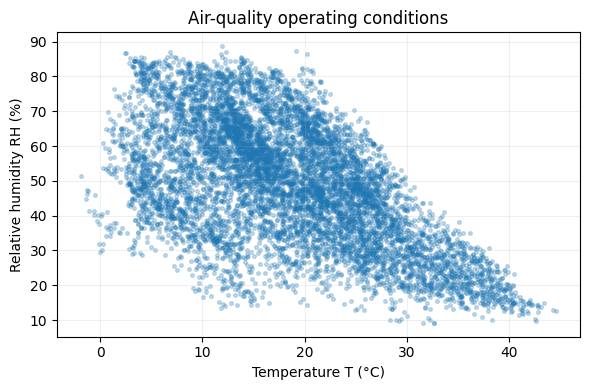

In [2]:
fig,ax=plt.subplots(figsize=(6,4)); ax.scatter(df["T"],df["RH"],s=7,alpha=.25)
ax.set(xlabel="Temperature T (°C)",ylabel="Relative humidity RH (%)",title="Air-quality operating conditions"); ax.grid(alpha=.2); fig.tight_layout(); fig.savefig(RESULTS/"temperature_humidity.png",dpi=160); plt.show()

## 2. Mamdani-style ventilation controller

We use three membership functions for temperature, humidity, and ventilation demand. Rule firing uses `min` for AND, rule aggregation uses `max`, and the final crisp output is the centroid of the aggregated output set.

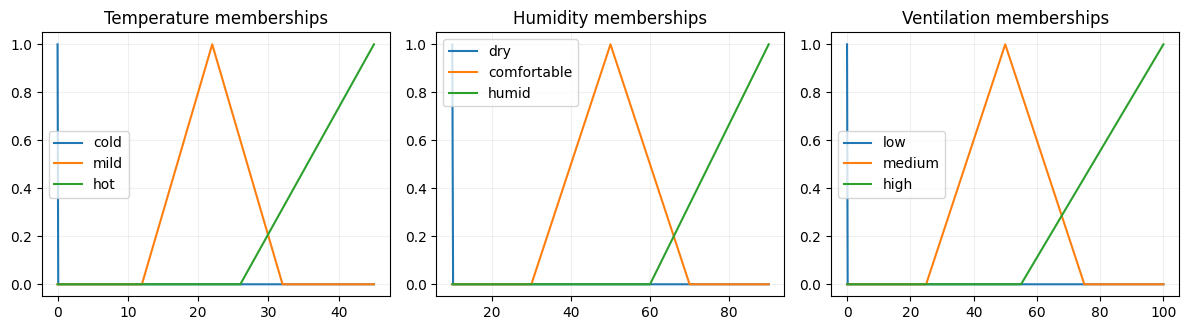

In [3]:
def trimf(x,a,b,c):
    x=np.asarray(x,dtype=float); y=np.zeros_like(x)
    if b>a: y=np.maximum(y,np.minimum((x-a)/(b-a),1.0))
    else: y=np.where(x<=b,1.0,y)
    if c>b: y=np.minimum(y,np.maximum((c-x)/(c-b),0.0))
    else: y=np.where(x>=b,np.minimum(y,1.0),y)
    y=np.where((x<a)|(x>c),0.0,y)
    if a==b: y=np.where(x<=b,1.0,y)
    if b==c: y=np.where(x>=b,1.0,y)
    return np.clip(y,0,1)

T_u=np.linspace(0,45,451); RH_u=np.linspace(10,90,401); V_u=np.linspace(0,100,501)
T_mf={"cold":trimf(T_u,0,0,18),"mild":trimf(T_u,12,22,32),"hot":trimf(T_u,26,45,45)}
RH_mf={"dry":trimf(RH_u,10,10,40),"comfortable":trimf(RH_u,30,50,70),"humid":trimf(RH_u,60,90,90)}
V_mf={"low":trimf(V_u,0,0,45),"medium":trimf(V_u,25,50,75),"high":trimf(V_u,55,100,100)}

def interp_membership(universe,mf,value): return float(np.interp(value,universe,mf))

def ventilation(temp,rh):
    t={k:interp_membership(T_u,v,temp) for k,v in T_mf.items()}
    h={k:interp_membership(RH_u,v,rh) for k,v in RH_mf.items()}
    # Expert rules: high heat/humidity increases ventilation; cool/dry conditions reduce it.
    strengths={
        "low":max(min(t["cold"],h["dry"]),min(t["cold"],h["comfortable"])),
        "medium":max(min(t["mild"],h["dry"]),min(t["mild"],h["comfortable"]),min(t["cold"],h["humid"])),
        "high":max(t["hot"],h["humid"]),
    }
    agg=np.maximum.reduce([np.minimum(strengths[k],V_mf[k]) for k in ["low","medium","high"]])
    return float(np.sum(V_u*agg)/np.sum(agg)) if agg.sum()>0 else 50.0

fig,axes=plt.subplots(1,3,figsize=(12,3.4))
for k,v in T_mf.items(): axes[0].plot(T_u,v,label=k)
for k,v in RH_mf.items(): axes[1].plot(RH_u,v,label=k)
for k,v in V_mf.items(): axes[2].plot(V_u,v,label=k)
axes[0].set_title("Temperature memberships"); axes[1].set_title("Humidity memberships"); axes[2].set_title("Ventilation memberships")
for ax in axes: ax.legend(); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(RESULTS/"fuzzy_memberships.png",dpi=160); plt.show()

In [4]:
fixed=pd.DataFrame({"T_C":[10,20,35,25,40],"RH_pct":[30,50,50,80,80],
                    "expected":["low","medium","high","high","high"]})
fixed["ventilation_pct"]=[ventilation(t,h) for t,h in fixed[["T_C","RH_pct"]].itertuples(index=False,name=None)]
fixed.to_csv(RESULTS/"fuzzy_fixed_points.csv",index=False)
fixed.round(1)

,T_C,RH_pct,expected,ventilation_pct
0,10,30,low,50.0
1,20,50,medium,50.0
2,35,50,high,82.3
3,25,80,high,83.8
4,40,80,high,84.2


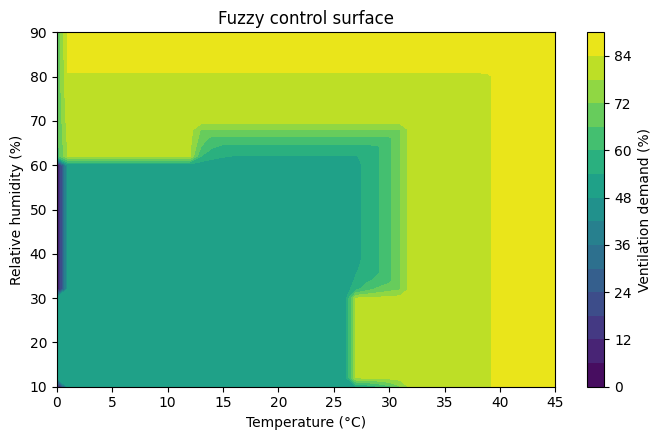

In [5]:
Ts=np.linspace(0,45,46); RHs=np.linspace(10,90,41); surface=np.array([[ventilation(t,h) for t in Ts] for h in RHs])
fig,ax=plt.subplots(figsize=(7,4.5)); im=ax.contourf(Ts,RHs,surface,levels=15); fig.colorbar(im,ax=ax,label="Ventilation demand (%)")
ax.set(xlabel="Temperature (°C)",ylabel="Relative humidity (%)",title="Fuzzy control surface"); fig.tight_layout(); fig.savefig(RESULTS/"fuzzy_control_surface.png",dpi=160); plt.show()

**Controller answer.** The rule base is monotonic in the intended direction: hot or humid conditions drive high ventilation, while cool/dry conditions remain low. The fixed-point table is an explicit sanity check; a smooth control surface is preferable to abrupt threshold switching.

## 3. ANFIS regression task

Target: `CO(GT)`. Inputs: `PT08.S1(CO)` and `PT08.S2(NMHC)`. The split is fixed at 70/15/15 with seed 42. Scaling is fitted on training data only.

In [6]:
task=df[["CO(GT)","PT08.S1(CO)","PT08.S2(NMHC)"]].dropna().reset_index(names="source_row")
idx=np.arange(len(task)); train_idx,temp_idx=train_test_split(idx,test_size=.30,random_state=42); val_idx,test_idx=train_test_split(temp_idx,test_size=.50,random_state=42)
split=np.full(len(task),"train",object); split[val_idx]="validation"; split[test_idx]="test"
pd.DataFrame({"source_row":task.source_row,"split":split}).to_csv(RESULTS/"split.csv",index=False)
X=task[["PT08.S1(CO)","PT08.S2(NMHC)"]].to_numpy(float); y=task["CO(GT)"].to_numpy(float)
scaler=StandardScaler().fit(X[train_idx]); Xs=scaler.transform(X)
print({"usable_rows":len(task),"train":len(train_idx),"validation":len(val_idx),"test":len(test_idx)})

{'usable_rows': 7344, 'train': 5140, 'validation': 1102, 'test': 1102}


In [7]:
class SugenoANFIS:
    """Small first-order Sugeno ANFIS for two-dimensional teaching examples."""
    def __init__(self,n_mfs=2,ridge=1e-4,maxiter=30):
        self.n_mfs=n_mfs; self.ridge=ridge; self.maxiter=maxiter
    def _unpack(self,theta):
        n=self.n_features*self.n_mfs
        return theta[:n].reshape(self.n_features,self.n_mfs), np.exp(theta[n:].reshape(self.n_features,self.n_mfs))
    def _weights(self,X,theta):
        centers,sigmas=self._unpack(theta); memberships=[]
        for j in range(self.n_features):
            z=(X[:,j,None]-centers[j][None,:])/sigmas[j][None,:]
            memberships.append(np.exp(-0.5*z*z))
        rules=np.array(list(product(range(self.n_mfs),repeat=self.n_features)))
        w=np.ones((len(X),len(rules)))
        for r,combo in enumerate(rules):
            for j,m in enumerate(combo): w[:,r]*=memberships[j][:,m]
        return w/(w.sum(axis=1,keepdims=True)+1e-12)
    def _design(self,X,theta):
        w=self._weights(X,theta); aug=np.column_stack([np.ones(len(X)),X])
        return np.hstack([w[:,r:r+1]*aug for r in range(w.shape[1])])
    def _fit_consequents(self,X,y,theta):
        Z=self._design(X,theta); A=Z.T@Z+self.ridge*np.eye(Z.shape[1])
        return np.linalg.solve(A,Z.T@y)
    def fit(self,X,y):
        self.n_features=X.shape[1]; qs=np.linspace(.25,.75,self.n_mfs)
        centers=np.vstack([np.quantile(X[:,j],qs) for j in range(self.n_features)])
        sigmas=np.vstack([np.repeat(max(np.std(X[:,j]),.5),self.n_mfs) for j in range(self.n_features)])
        theta0=np.r_[centers.ravel(),np.log(sigmas).ravel()]
        def objective(theta):
            coef=self._fit_consequents(X,y,theta); pred=self._design(X,theta)@coef
            return np.mean((y-pred)**2)
        n=self.n_features*self.n_mfs
        bounds=[(-3,3)]*n+[(np.log(.15),np.log(3.0))]*n
        self.optimization_=minimize(objective,theta0,method="L-BFGS-B",bounds=bounds,options={"maxiter":self.maxiter})
        self.theta_=self.optimization_.x; self.coef_=self._fit_consequents(X,y,self.theta_)
        return self
    def predict(self,X): return self._design(X,self.theta_)@self.coef_

In [8]:
def score_model(name,model):
    out={"model":name}
    for split_name,ii in [("validation",val_idx),("test",test_idx)]:
        p=model.predict(Xs[ii]); out[f"{split_name}_rmse"]=mean_squared_error(y[ii],p)**0.5; out[f"{split_name}_mae"]=mean_absolute_error(y[ii],p)
    return out

linear=LinearRegression().fit(Xs[train_idx],y[train_idx]); candidates=[]
for n_mfs in [2,3]:
    model=SugenoANFIS(n_mfs=n_mfs,maxiter=30).fit(Xs[train_idx],y[train_idx])
    row=score_model(f"ANFIS-{n_mfs}MF",model); row["model_object"]=model; candidates.append(row)
lin_row=score_model("Linear regression",linear)
choice=min(candidates,key=lambda r:r["validation_rmse"]); anfis=choice.pop("model_object")
for r in candidates:
    r.pop("model_object",None)
metrics=pd.DataFrame([lin_row,*candidates])
metrics.to_csv(RESULTS/"metrics.csv",index=False)
metrics.round(4)

,model,validation_rmse,validation_mae,test_rmse,test_mae
0,Linear regression,0.5103,0.3722,0.5365,0.3821
1,ANFIS-2MF,0.4548,0.3194,0.4714,0.3263
2,ANFIS-3MF,0.4486,0.3151,0.4672,0.3248


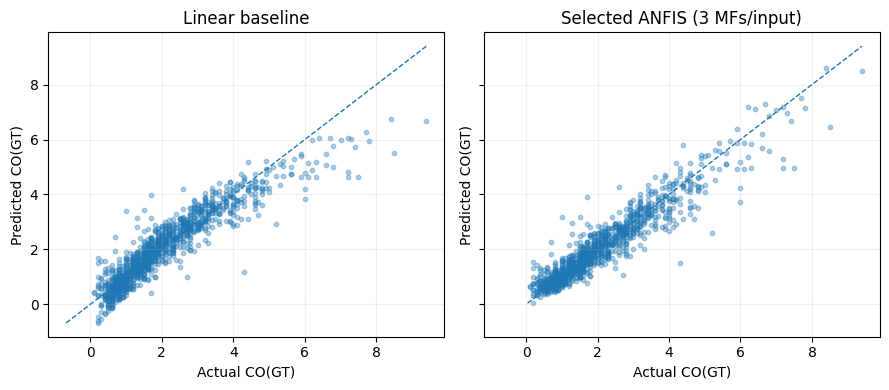

Selected: ANFIS-3MF
Test RMSE improvement over linear: 12.9%


In [9]:
pred_lin=linear.predict(Xs[test_idx]); pred_anfis=anfis.predict(Xs[test_idx])
fig,axes=plt.subplots(1,2,figsize=(9,4),sharex=True,sharey=True)
for ax,p,title in zip(axes,[pred_lin,pred_anfis],["Linear baseline",f"Selected ANFIS ({anfis.n_mfs} MFs/input)"]):
    ax.scatter(y[test_idx],p,s=10,alpha=.35); lo=min(y[test_idx].min(),p.min()); hi=max(y[test_idx].max(),p.max()); ax.plot([lo,hi],[lo,hi],'--',linewidth=1)
    ax.set(title=title,xlabel="Actual CO(GT)",ylabel="Predicted CO(GT)"); ax.grid(alpha=.2)
fig.tight_layout(); fig.savefig(RESULTS/"predicted_vs_actual.png",dpi=160); plt.show()
selected=metrics.loc[metrics.model.str.startswith("ANFIS")].sort_values("validation_rmse").iloc[0]
linear_row=metrics.loc[metrics.model=="Linear regression"].iloc[0]
print("Selected:",selected.model)
print("Test RMSE improvement over linear: {:.1%}".format(1-selected.test_rmse/linear_row.test_rmse))

## Worked interpretation

The fuzzy controller and ANFIS solve different problems: the controller encodes **expert policy** and is easy to audit; ANFIS learns a **nonlinear regression surface** from sensor data. On this dataset, the selected ANFIS model improves test RMSE over ordinary linear regression, so the extra nonlinear structure is useful. It should still be treated cautiously: air-quality sensor measurements contain missing values, drift, and temporal dependence that this simple random split does not model.